<h1>Chapter 5 | Data Exercise #5 | <code>World Development Indicators</code> | Generalizing from Data</h1>


<h2>Introduction:</h2>
<p>In this notebook, you will find my notes and code for Chapter 5's <b>exercise 5</b> of the book <a href="https://gabors-data-analysis.com/">Data Analysis for Business, Economics, and Policy</a>, by Gábor Békés and Gábor Kézdi. The question was: 

<p>5. Download the most recent data from the world development indicators website on GDP per capita and CO2 emission per capita.
<p>Assignments:</p>
<ul>
    <li>Divide countries into two groups by their GDP per capita and calculate the average difference in CO2 emission per capita between the two groups.</li>
    <li>Use bootstrap to estimate its standard error. </li>
    <li>Create the appropriate 95% CI.</li>
    <li>Interpret the results.</li>
</ul>
<h2>1. Load the data</h2>

In [51]:
import os
import pandas as pd
import warnings
from datetime import datetime
from plotnine import *
import sys
import numpy as np
from scipy.stats import norm, sem
from numpy.random import choice
import wbgapi as wb
warnings.filterwarnings("ignore")

In [52]:
# Increase number of returned rows in pandas
pd.set_option("display.max_rows", 500)

In [53]:
# Current script folder
dirname = os.getcwd()

# Get location folders

data_out = f"{dirname}/da_data_exercises/ch05-generalizing_from_data/05-WDI_CO2_GDP/data/clean/"
output = f"{dirname}/da_data_exercises/ch05-generalizing_from_data/05-WDI_CO2_GDP/data/output/"
func = f"{dirname}/da_case_studies/ch00-tech_prep/"
sys.path.append(func)
paths = [data_out, output]

for path in paths:
    if not os.path.exists(path):
        os.makedirs(path)

## 1.1 Download the most recent data from the world development indicators website on GDP per capita and CO2 emission per capita.
While we could use the World Bank's APIs, there are several tools developed by others that already did the heavy lifting and can make our life easier. `wbgapi` is one among many. Let's learn a bit about it and use it in our favor.

For now, let's play around with it.

In [54]:
help(wb)

Help on package wbgapi:

NAME
    wbgapi

DESCRIPTION
    wbgapi provides a comprehensive interface to the World Bank's data and
    metadata API with built-in pandas integration

PACKAGE CONTENTS
    __version__
    data
    economy
    economy_coder
    economy_metadata
    income
    lending
    region
    series
    series_metadata
    source
    time
    topic
    utils

CLASSES
    builtins.Exception(builtins.BaseException)
        APIError
            APIResponseError
        URLError
    builtins.dict(builtins.object)
        Coder
    builtins.object
        Featureset
        Metadata
        MetadataCollection

    class APIError(builtins.Exception)
     |  APIError(url, msg, code=None)
     |
     |  Method resolution order:
     |      APIError
     |      builtins.Exception
     |      builtins.BaseException
     |      builtins.object
     |
     |  Methods defined here:
     |
     |  __init__(self, url, msg, code=None)
     |      Initialize self.  See help(type(self))

In [55]:
help(wb.series)

Help on module wbgapi.series in wbgapi:

NAME
    wbgapi.series - Access information about series in a database

FUNCTIONS
    Series(id='all', q=None, topic=None, db=None, name='SeriesName')
        Return a pandas Series by calling list

    get(id, db=None)
        Retrieve a specific series object

        Arguments:
            id:     the series identifier

            db:     database; pass None to access the global database

        Returns:
            a series object

        Example:
            print(wbgapi.series.get('SP.POP.TOTL')['value'])

    info(id='all', q=None, topic=None, db=None)
        Print a user report of series. This can be time consuming
        for large databases like the WDI if 'all' series are requested.

        Arguments:
            id:         a series identifier or list-like of identifiers

            q:          search string (on series name))

            topic:      topic ID or list-like

            db:         database; pass None to access t

In [56]:
wb.source.info()

id,name,code,concepts,lastupdated
1,Doing Business,DBS,3,2021-08-18
2,World Development Indicators,WDI,3,2025-12-16
3,Worldwide Governance Indicators,WGI,3,2024-11-05
5,Subnational Malnutrition Database,SNM,3,2016-03-21
6,International Debt Statistics,IDS,4,2025-12-03
11,Africa Development Indicators,ADI,3,2013-02-22
12,Education Statistics,EDS,3,2024-06-25
13,Enterprise Surveys,ESY,3,2022-03-25
14,Gender Statistics,GDS,3,2025-11-11
15,Global Economic Monitor,GEM,3,2025-12-17


Fortunately, this awesome package has a search string parameter to help us. Let's try it out.

In [57]:
wb.series.info(q="GDP per capita")

id,value
NY.GDP.PCAP.CD,GDP per capita (current US$)
NY.GDP.PCAP.CN,GDP per capita (current LCU)
NY.GDP.PCAP.KD,GDP per capita (constant 2015 US$)
NY.GDP.PCAP.KD.ZG,GDP per capita growth (annual %)
NY.GDP.PCAP.KN,GDP per capita (constant LCU)
NY.GDP.PCAP.PP.CD,"GDP per capita, PPP (current international $)"
NY.GDP.PCAP.PP.KD,"GDP per capita, PPP (constant 2021 international $)"
,7 elements


In [58]:
# 2. Search for CO2 emissions
wb.series.info(db=None, q="CO2")

id,value
EN.GHG.CO2.AG.MT.CE.AR5,Carbon dioxide (CO2) emissions from Agriculture (Mt CO2e)
EN.GHG.CO2.BU.MT.CE.AR5,Carbon dioxide (CO2) emissions from Building (Energy) (Mt CO2e)
EN.GHG.CO2.FE.MT.CE.AR5,Carbon dioxide (CO2) emissions from Fugitive Emissions (Energy) (Mt CO2e)
EN.GHG.CO2.IC.MT.CE.AR5,Carbon dioxide (CO2) emissions from Industrial Combustion (Energy) (Mt CO2e)
EN.GHG.CO2.IP.MT.CE.AR5,Carbon dioxide (CO2) emissions from Industrial Processes (Mt CO2e)
EN.GHG.CO2.LU.DF.MT.CE.AR5,Carbon dioxide (CO2) net fluxes from LULUCF - Deforestation (Mt CO2e)
EN.GHG.CO2.LU.FL.MT.CE.AR5,Carbon dioxide (CO2) net fluxes from LULUCF - Forest Land (Mt CO2e)
EN.GHG.CO2.LU.MT.CE.AR5,Carbon dioxide (CO2) net fluxes from LULUCF - Total excluding non-tropical fires (Mt CO2e)
EN.GHG.CO2.LU.OL.MT.CE.AR5,Carbon dioxide (CO2) net fluxes from LULUCF - Other Land (Mt CO2e)
EN.GHG.CO2.LU.OS.MT.CE.AR5,Carbon dioxide (CO2) net fluxes from LULUCF - Organic Soil (Mt CO2e)


In [59]:
for row in wb.data.fetch("EN.GHG.CO2.PC.CE.AR5", "BRA"):
    print(row)

{'value': 2.31826466114939, 'series': 'EN.GHG.CO2.PC.CE.AR5', 'economy': 'BRA', 'aggregate': False, 'time': 'YR2024'}
{'value': 2.27447826989363, 'series': 'EN.GHG.CO2.PC.CE.AR5', 'economy': 'BRA', 'aggregate': False, 'time': 'YR2023'}
{'value': 2.27889577215227, 'series': 'EN.GHG.CO2.PC.CE.AR5', 'economy': 'BRA', 'aggregate': False, 'time': 'YR2022'}
{'value': 2.41580858865319, 'series': 'EN.GHG.CO2.PC.CE.AR5', 'economy': 'BRA', 'aggregate': False, 'time': 'YR2021'}
{'value': 2.1466461829, 'series': 'EN.GHG.CO2.PC.CE.AR5', 'economy': 'BRA', 'aggregate': False, 'time': 'YR2020'}
{'value': 2.25869881785082, 'series': 'EN.GHG.CO2.PC.CE.AR5', 'economy': 'BRA', 'aggregate': False, 'time': 'YR2019'}
{'value': 2.28562350357953, 'series': 'EN.GHG.CO2.PC.CE.AR5', 'economy': 'BRA', 'aggregate': False, 'time': 'YR2018'}
{'value': 2.41694955353585, 'series': 'EN.GHG.CO2.PC.CE.AR5', 'economy': 'BRA', 'aggregate': False, 'time': 'YR2017'}
{'value': 2.37533549789759, 'series': 'EN.GHG.CO2.PC.CE.AR5'

In [60]:
wb.data.DataFrame(["EN.GHG.CO2.PC.CE.AR5", "NY.GDP.PCAP.PP.CD"], "BRA", mrv=10)

,YR2015,YR2016,YR2017,YR2018,YR2019,YR2020,YR2021,YR2022,YR2023,YR2024
series,,,,,,,,,,
EN.GHG.CO2.PC.CE.AR5,2.568189,2.375335,2.41695,2.285624,2.258699,2.146646,2.415809,2.278896,2.274478,2.318265
NY.GDP.PCAP.PP.CD,14821.438318,14309.206149,14559.04889,15463.742639,16069.838015,16101.618306,18075.706005,19876.853353,21175.618699,22338.476564


Great! We've identified our series. We need to work with:
- `NY.GDP.PCAP.PP.CD` –	GDP per capita, PPP (current international $)
- `EN.GHG.CO2.PC.CE.AR5` – Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)

### 1.1.1 Fetch and Clean Data
First, we'll define our indicators. We map the complex codes to simpler names.

In [61]:
indicators = {
    "NY.GDP.PCAP.PP.CD": "GDP_PPP",
    "EN.GHG.CO2.PC.CE.AR5": "CO2_Capita"
}

Then, we can fetch data for the last 10 years. That should suffice.

In [62]:
df_raw = wb.data.DataFrame(indicators,
                           economy="all",
                           time=range(2014, 2025),
                           skipAggs=True, # Remove regional/world aggregates
                           numericTimeKeys=True, # Return years as integers
                           labels=True, # Add Country Column name
                           columns="series"
                           )

In [63]:
df_raw.head()

Country  Time  EN.GHG.CO2.PC.CE.AR5  NY.GDP.PCAP.PP.CD
economy time                                                         
ZWE     2024  Zimbabwe  2024              0.772821        5928.080625
        2023  Zimbabwe  2023              0.768994        5791.192129
        2022  Zimbabwe  2022              0.719221        5395.856298
        2021  Zimbabwe  2021              0.688925        4827.088694
        2020  Zimbabwe  2020              0.584444        4178.585579

In [64]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 2387 entries, ('ZWE', np.int64(2024)) to ('AFG', np.int64(2014))
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country               2387 non-null   object 
 1   Time                  2387 non-null   object 
 2   EN.GHG.CO2.PC.CE.AR5  2233 non-null   float64
 3   NY.GDP.PCAP.PP.CD     2175 non-null   float64
dtypes: float64(2), object(2)
memory usage: 156.4+ KB


Awesome! Now, we need to clean the index/columns.

In [65]:
df = df_raw.reset_index()
df.head()

,economy,time,Country,Time,EN.GHG.CO2.PC.CE.AR5,NY.GDP.PCAP.PP.CD
0,ZWE,2024,Zimbabwe,2024,0.772821,5928.080625
1,ZWE,2023,Zimbabwe,2023,0.768994,5791.192129
2,ZWE,2022,Zimbabwe,2022,0.719221,5395.856298
3,ZWE,2021,Zimbabwe,2021,0.688925,4827.088694
4,ZWE,2020,Zimbabwe,2020,0.584444,4178.585579


Our dictionary values were not passed as column names. Let's try to fix that as well.

In [66]:
df = df.rename(columns=indicators)

In [67]:
df.head()

,economy,time,Country,Time,CO2_Capita,GDP_PPP
0,ZWE,2024,Zimbabwe,2024,0.772821,5928.080625
1,ZWE,2023,Zimbabwe,2023,0.768994,5791.192129
2,ZWE,2022,Zimbabwe,2022,0.719221,5395.856298
3,ZWE,2021,Zimbabwe,2021,0.688925,4827.088694
4,ZWE,2020,Zimbabwe,2020,0.584444,4178.585579


We can now drop wors where GDP or CO2 is missing.


In [68]:
df.isnull().sum()

economy         0
time            0
Country         0
Time            0
CO2_Capita    154
GDP_PPP       212
dtype: int64

In [69]:
df_complete = df.dropna(subset=["GDP_PPP", "CO2_Capita"])
df_complete.sample(5)

,economy,time,Country,Time,CO2_Capita,GDP_PPP
944,MNG,2015,Mongolia,2015,5.955306,10458.302724
2261,AUT,2018,Austria,2018,7.607108,56636.495303
1296,JOR,2015,Jordan,2015,2.685608,8967.079958
1678,ETH,2018,Ethiopia,2018,0.155059,2095.317578
630,QAT,2021,Qatar,2021,47.283974,116832.656942


Now, we can sort our DataFrame. Later on, we'll keep the most recent year per country.

In [70]:
df_final = df_complete.sort_values(["Country", "time"], ascending=[True, False])
df_final.head()

,economy,time,Country,Time,CO2_Capita,GDP_PPP
2377,AFG,2023,Afghanistan,2023,0.280995,2201.722907
2378,AFG,2022,Afghanistan,2022,0.278421,2122.995815
2379,AFG,2021,Afghanistan,2021,0.312157,2144.166570
2380,AFG,2020,Afghanistan,2020,0.310825,2561.981761
2381,AFG,2019,Afghanistan,2019,0.319753,2583.485332


In [71]:
df_final = df_final.rename(columns={
    "economy": "Country_ISO",
    "Time": "Year"})

In [72]:
df_final = df_final.drop(columns="time").reset_index(drop=True)
df_final

,Country_ISO,Country,Year,CO2_Capita,GDP_PPP
0,AFG,Afghanistan,2023,0.280995,2201.722907
1,AFG,Afghanistan,2022,0.278421,2122.995815
2,AFG,Afghanistan,2021,0.312157,2144.166570
3,AFG,Afghanistan,2020,0.310825,2561.981761
4,AFG,Afghanistan,2019,0.319753,2583.485332
...,...,...,...,...,...
2081,ZWE,Zimbabwe,2018,0.816285,3992.890719
2082,ZWE,Zimbabwe,2017,0.714789,10756.445442
2083,ZWE,Zimbabwe,2016,0.771813,4275.449351
2084,ZWE,Zimbabwe,2015,0.881442,4045.898647


### 1.1.2 Keep Latest Data
For our analysis, we'll want to work with the latest data available for each country only.

In [73]:
df_latest = df_final.drop_duplicates(subset="Country_ISO", keep="first")
df_latest

,Country_ISO,Country,Year,CO2_Capita,GDP_PPP
0,AFG,Afghanistan,2023,0.280995,2201.722907
10,ALB,Albania,2024,1.785221,26693.193437
21,DZA,Algeria,2024,3.980800,17620.742396
32,AGO,Angola,2024,0.741712,10118.608995
43,ATG,Antigua and Barbuda,2024,3.798575,33386.191713
54,ARG,Argentina,2024,4.010665,30431.193122
65,ARM,Armenia,2024,2.470282,22823.179526
76,ABW,Aruba,2024,5.148386,50649.301523
87,AUS,Australia,2024,14.097354,71410.419875
98,AUT,Austria,2024,6.322784,71621.803364


In [74]:
print(f"Columns fixed: {df_latest.columns.tolist()}")
print(df_latest.head())

Columns fixed: ['Country_ISO', 'Country', 'Year', 'CO2_Capita', 'GDP_PPP']
   Country_ISO              Country  Year  CO2_Capita       GDP_PPP
0          AFG          Afghanistan  2023    0.280995   2201.722907
10         ALB              Albania  2024    1.785221  26693.193437
21         DZA              Algeria  2024    3.980800  17620.742396
32         AGO               Angola  2024    0.741712  10118.608995
43         ATG  Antigua and Barbuda  2024    3.798575  33386.191713


## 1.2 Exploratory Analysis
Before moving on to our next steps, let's perform a quick exploratory analysis of our dataset. We'll focus on CO2 emissions.

### 1.2.1 Dealing with Outliers
Before moving to the next step, it is always a good idea to visualize the distribution of our dataset and check for possible outliers. To do this, we should look at `CO2_Capita` in two ways.
1. **Histogram**: Visualize the shape
2. **Boxplot**: specifically flag points that are statistically "far" from the rest.

Let's first sort our data according to CO2 emissions.

In [75]:
df_latest.sort_values(by="CO2_Capita", ascending=False).head(10)

,Country_ISO,Country,Year,CO2_Capita,GDP_PPP
1447,PLW,Palau,2023,78.857111,18230.269863
1545,QAT,Qatar,2024,47.332164,126046.354856
131,BHR,Bahrain,2024,23.899992,66941.243037
1019,KWT,Kuwait,2024,23.672672,52443.596922
273,BRN,Brunei Darussalam,2024,20.242652,89879.361498
1891,TTO,Trinidad and Tobago,2024,19.581052,36328.513007
1425,OMN,Oman,2024,18.651991,41740.165853
1611,SAU,Saudi Arabia,2024,18.484584,71375.372789
1978,ARE,United Arab Emirates,2024,18.255206,79228.738801
87,AUS,Australia,2024,14.097354,71410.419875


In [76]:
df_latest["CO2_Capita"].describe()

count    191.000000
mean       4.516837
std        7.707716
min        0.000000
25%        0.753625
50%        2.621130
75%        5.166069
max       78.857111
Name: CO2_Capita, dtype: float64

In [77]:
outlier_row = df_latest.loc[df_latest["CO2_Capita"].idxmax()]
max_val = outlier_row["CO2_Capita"]
max_name = outlier_row["Country"]

In [78]:
histogram = (
    ggplot(df_latest, aes(x="CO2_Capita"))
    + geom_histogram(fill="skyblue", color="white", bins=30)
    + labs(title="Distribution of CO2 Emissions", x="Tons per Capita", y="Count")
    + scale_y_continuous(expand=[0,0])
    + coord_cartesian(ylim=[0,70])
    + theme_bw()
)

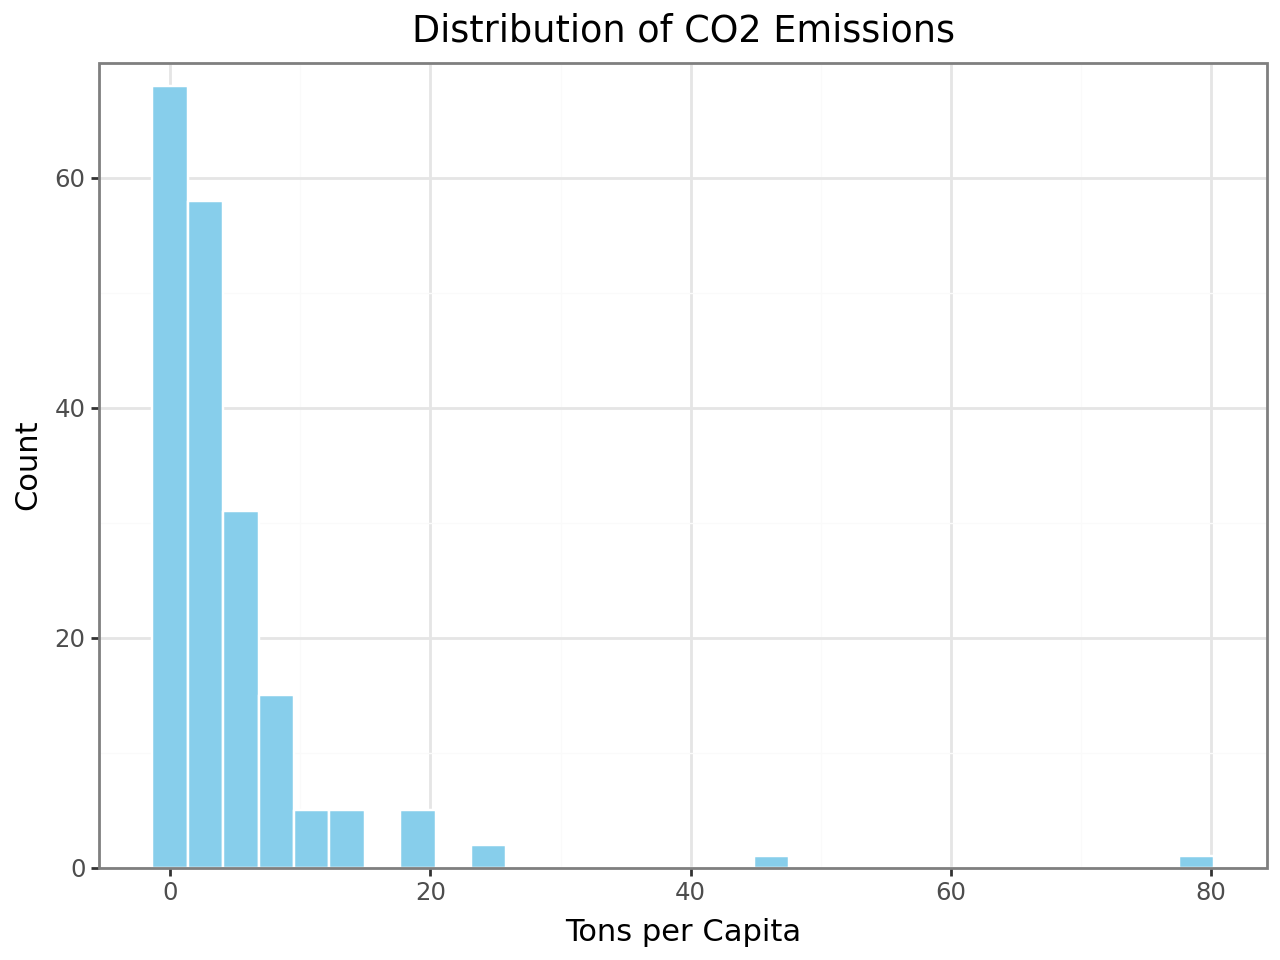

In [79]:
histogram

In [80]:
# Create dummy column
df_latest["World"] = "All Countries"
boxplot = (ggplot(df_latest, aes(x="World", y="CO2_Capita"))  
    + geom_boxplot(fill="orange", alpha=0.6, outlier_color="red", outlier_size=3)
    + labs(title="Boxplot identifying Extreme Outliers", x="", y="Tons Per Capita")
    + theme_bw()
    + theme(axis_text_x=element_blank())
    )

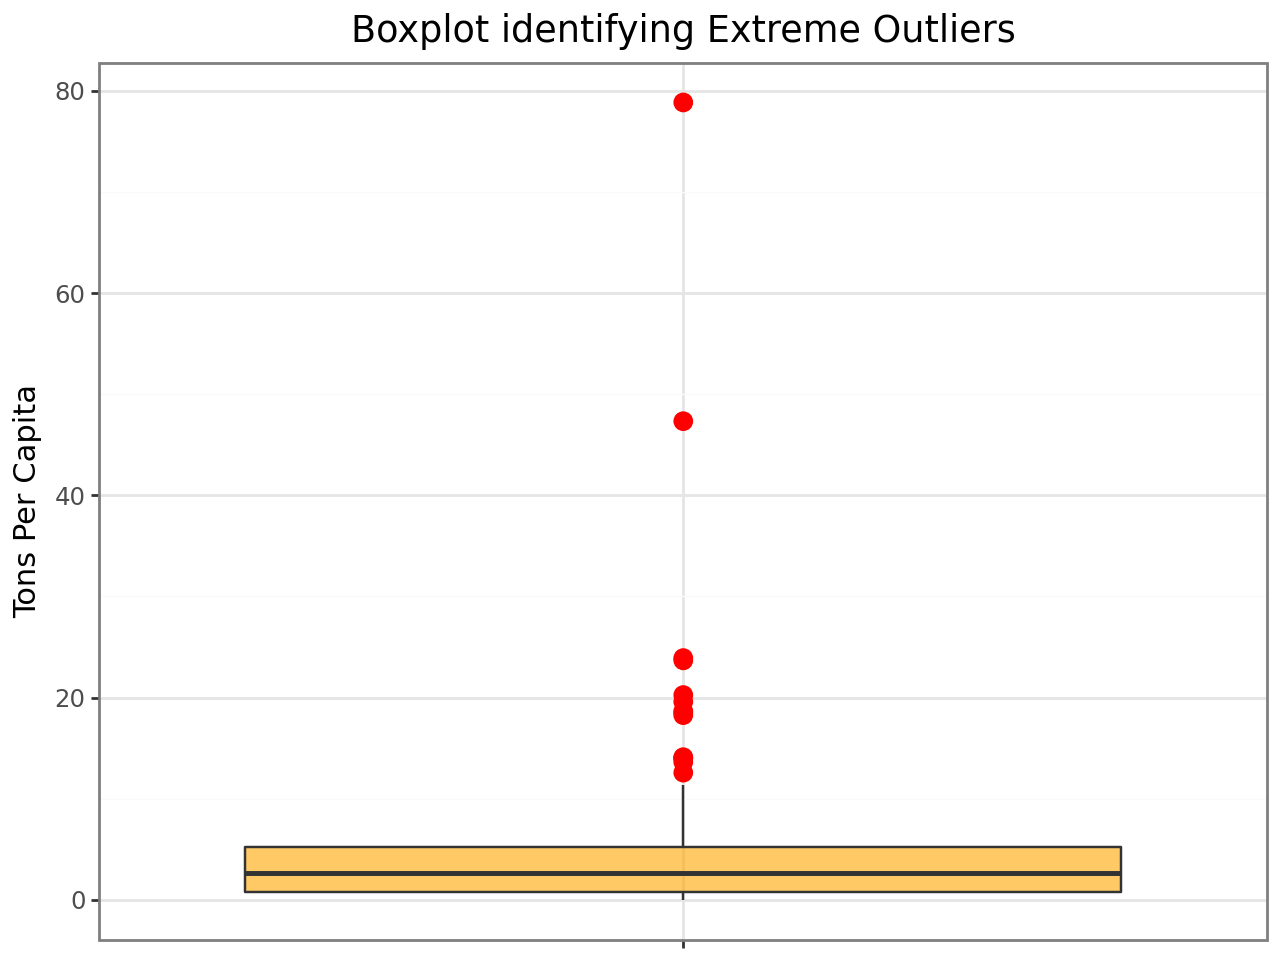

In [81]:
boxplot

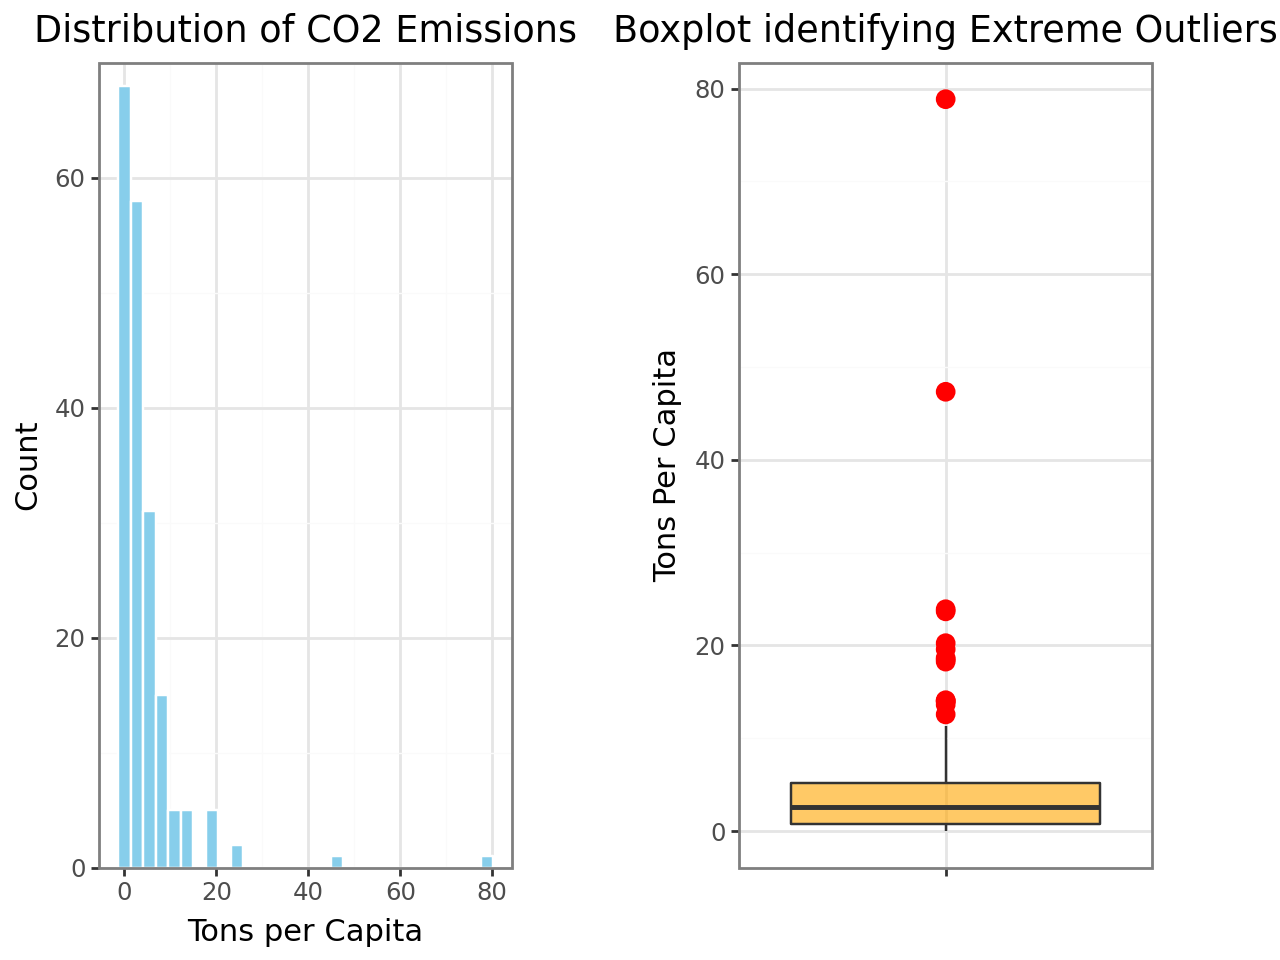

In [82]:
(histogram | boxplot) + theme(plot_margin_left=0.1, plot_margin_right=0.1)

**Findings**:
- We can see that there is a clear degree of skewness in our dataset. The histogram displays a high frequency of countries in the 0-20 ton range, with a handful of countries above this value.
- The boxplot helps us visualize this skewness even further. We can see that the interquartile range is located at a very narrow interval, even narrower than we thought. Let's quickly plot a table with these findings.

In [83]:
q1 = df_latest["CO2_Capita"].quantile(0.25)
q3 = df_latest["CO2_Capita"].quantile(0.75)

IQR = q3 - q1
median = df_latest["CO2_Capita"].median()

# Define the "whisker" limit
upper_whisker = q3 + (1.5 * IQR)

# Count countries in each section
n_total = len(df_latest)
n_outliers = len(df_latest[df_latest["CO2_Capita"] > upper_whisker])
n_regular = n_total - n_outliers

# Create table
summary_df = pd.DataFrame({
    "Metric": ["25th Percentile (Q1)", "Median (Q2)", "75th Percentile (Q3)", "IQR", "Upper Whisker Limit"],
    "Value (Tons)": [q1, median, q3, IQR, upper_whisker]
    }
)

print("--- Boxplot Statistics ---")
print(summary_df.round(2))

print(f"\n--- Distribution Counts ---")
print(f"Total Countries: {n_total}")
print(f"Regular Data (Below {upper_whisker:.2f}):   {n_regular} countries")
print(f"Outliers (Above {upper_whisker:.2f}):   {n_outliers} countries (red dots)")

# List outliers
print("\n--- Outliers ---")
outliers_latest = df_latest[df_latest["CO2_Capita"] > upper_whisker].sort_values("CO2_Capita", ascending=False)
print(outliers_latest[["Country", "CO2_Capita"]])


--- Boxplot Statistics ---
                 Metric  Value (Tons)
0  25th Percentile (Q1)          0.75
1           Median (Q2)          2.62
2  75th Percentile (Q3)          5.17
3                   IQR          4.41
4   Upper Whisker Limit         11.78

--- Distribution Counts ---
Total Countries: 191
Regular Data (Below 11.78):   177 countries
Outliers (Above 11.78):   14 countries (red dots)

--- Outliers ---
                   Country  CO2_Capita
1447                 Palau   78.857111
1545                 Qatar   47.332164
131                Bahrain   23.899992
1019                Kuwait   23.672672
273      Brunei Darussalam   20.242652
1891   Trinidad and Tobago   19.581052
1425                  Oman   18.651991
1611          Saudi Arabia   18.484584
1978  United Arab Emirates   18.255206
87               Australia   14.097354
350                 Canada   13.998358
1567    Russian Federation   13.997772
2000         United States   13.619569
975             Kazakhstan   12.56781

**Findings**:
- Solely based on countries that would be outside the upper whisker, we could flag several countries as outliers.
- **However**, one country really stands out: **Palau**. A tiny island with a very small population yet dependent on carbon-intensive activities related to touriesm, for instance.
- Other countries such as **Qatar** and **Bahrain**, even though well above the upper whisker limit, should **not** be considered outliers. They are resource-rich nations and removing them would hide the possible reality that Higher Income may lead to massive emissions. We want to capture this variance in our bootstrap.

**Decision**:
- We will **remove Palau** from our dataset, as is nearly 2 times higher than its nearest neighbor. The other nearest countries will be **kept** as they mostly represent a valid cluster of high-income oil economies.

In [84]:
df_latest = df_latest[df_latest["Country"] != "Palau"]
print(f"Dropped Palau. New Max CO2: {df_latest["CO2_Capita"].max():.2f} ({df_latest.loc[df_latest["CO2_Capita"].idxmax()]["Country"]})")

Dropped Palau. New Max CO2: 47.33 (Qatar)


Awesome! We can move on to our next step.
# 2. Divide countries into two groups by their GDP per capita and calculate the average difference in CO2 emission per capita between the two groups.
## 2.1 Grouping countries by GDP
First, we need to define a cutoff line to divide our countries. We can use the median GDP.

In [85]:
median_gdp  = df_latest["GDP_PPP"].median()
print(f"The cutoff line (Median GDP) is : ${median_gdp:.2f}")

The cutoff line (Median GDP) is : $20025.85


Ok! Now we can create our groups based on this median.

In [86]:
# Use .copy() to avoid warnings
df_latest = df_latest.copy()
df_latest["Group"] = np.where(df_latest["GDP_PPP"] > median_gdp, "High Income", "Low Income")

In [87]:
df_latest.sample(10)

,Country_ISO,Country,Year,CO2_Capita,GDP_PPP,World,Group
175,BEL,Belgium,2024,7.306615,72236.905055,All Countries,High Income
2064,ZMB,Zambia,2024,0.542961,4214.892778,All Countries,Low Income
1392,NGA,Nigeria,2024,0.566918,9086.875506,All Countries,Low Income
1765,VCT,St. Vincent and the Grenadines,2024,1.311919,21272.080067,All Countries,High Income
415,COL,Colombia,2024,1.797804,21508.780248,All Countries,High Income
219,BTN,Bhutan,2023,1.984651,16215.152007,All Countries,Low Income
350,CAN,Canada,2024,13.998358,65463.099099,All Countries,High Income
361,CYM,Cayman Islands,2023,4.920726,88427.786671,All Countries,High Income
1337,NPL,Nepal,2024,0.535964,5736.621343,All Countries,Low Income
1967,UKR,Ukraine,2024,3.129348,18550.462891,All Countries,Low Income


## 2.1 Calculate the average difference in CO2 emission per capita between the two groups

In [88]:
group_stats = df_latest.groupby(by="Group")["CO2_Capita"].mean()
group_stats

Group
High Income    6.847820
Low Income     1.403324
Name: CO2_Capita, dtype: float64

We can see that the average CO2 emissions per capita is quite different between the two groups. Let's see the average difference now.

In [89]:
actual_diff = group_stats["High Income"] - group_stats["Low Income"]
print(f"Higher income countries emit {actual_diff:.2f} tons more CO2 than lower income countries. ")

Higher income countries emit 5.44 tons more CO2 than lower income countries. 


# 3. Use bootstrap to estimate its standard error
Because we defined our groups using the **Median GDP**, the line between high and low income is not fixed in stone. Samples could return slightly different median values and some borderline countries might swap groups. As such, we must capture this uncertainty.
1. **Resample** the entire list of countries.
2. **Recalculate** the median GDP for this specific sample.
3. **Re-split** into higher/lower income.
4. **Calculate** the difference in CO2.

In [90]:
def bootstrap_gap(df, n_iterations=3000):
    stats = []
    n_obs = len(df)

    # Convert DataFrame columns to NumPy arrays for speed inside the loop
    gdp_data = df["GDP_PPP"].values
    co2_data = df["CO2_Capita"].values

    print(f"Boostrapping {n_iterations} times...")

    for _ in range(n_iterations):
        # 1. Resample Indices (keeping GDP and CO2 paired for each country)
        indices = np.random.choice(n_obs, n_obs, replace=True)
        sample_gdp = gdp_data[indices]
        sample_co2 = co2_data[indices]

        # 2. Dynamic Split: Find the new median for this sample
        median_split = np.median(sample_gdp)

        # 3. Separate groups
        # Mask for higher income (> Median)
        is_high_income = sample_gdp > median_split

        # 4. Calculate Means
        # We use simple boolean indexing
        mean_high = np.mean(sample_co2[is_high_income])
        mean_low = np.mean(sample_co2[~is_high_income])

        # 5. Store the difference
        stats.append(mean_high - mean_low)

    return np.array(stats)

We can now run our bootstrap.

In [91]:
bootstrap_diffs = bootstrap_gap(df_latest)

Boostrapping 3000 times...


In [92]:
bootstrap_diffs

array([4.92401412, 5.91384031, 4.49667456, ..., 5.97343417, 4.07842754,
       5.92597016])

# 4. Create the appropriate 95% CI


In [93]:
CI_lower = np.percentile(bootstrap_diffs, 2.5)
CI_upper = np.percentile(bootstrap_diffs, 97.5)

se_diff = np.std(bootstrap_diffs)

In [94]:
print("--- Results ---")
print(f"Point Estimate (Gap): {actual_diff:.2f} tons")
print(f"Standard Error  {se_diff:.3f}")
print(f"95% CI of the Gap: [{CI_lower:.2f}, {CI_upper:.2f}]")

--- Results ---
Point Estimate (Gap): 5.44 tons
Standard Error  0.698
95% CI of the Gap: [4.29, 7.00]


# 5. Interpret the results


We estimate that Higher Income countries emit, on average, **5.44** tons more CO2 per capita than lower income countries.
- **Uncertainty**: The 95% Interval is **[4.29, 7.00]**.
- **Significance**: Since the interval **does not include zero**, we could reject the null hypothesis that lower income countries emit the same or more CO2 than rich countries.
  - We are 95% confident that a positive "Emission Gap" exists, even if the exact magnitude varies significantly depending on the specific countries sampled.
- **External Validity**: This gap represents the structural inequality of the current global economy, where wealth creation is still strongly correlated with higher carbon footprints.